In [190]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
from scipy.stats import expon, skew
from scipy.special import factorial
from statsmodels.distributions.empirical_distribution import ECDF

# Для воспроизводимости
np.random.seed(42)

n = 25
sample = np.random.exponential(scale=1, size=n)
print("Выборка:", sample)

Выборка: [0.46926809 3.01012143 1.31674569 0.91294255 0.16962487 0.16959629
 0.05983877 2.01123086 0.91908215 1.23125006 0.02079931 3.50355748
 1.78642954 0.23868763 0.20067899 0.20261142 0.36275373 0.74392783
 0.56553707 0.34422299 0.94637087 0.15023453 0.34551551 0.45627722
 0.60893469]


In [191]:
# a)

unique_values, counts = np.unique(sample, return_counts=True)
if np.max(counts) == 1:
    mode_est = None
    print(f"Моды нет (все значения уникальны)")
else:
    mode_est = unique_values[counts == np.max(counts)][0]
    print(f"Мода: {mode_est:.3f}")

median_est = np.median(sample)
range_est = np.max(sample) - np.min(sample)
skew_est = skew(sample)

print(f"Медиана: {median_est:.3f}")
print(f"Размах: {range_est:.3f}")
print(f"Коэффициент асимметрии: {skew_est:.3f}")

Моды нет (все значения уникальны)
Медиана: 0.469
Размах: 3.483
Коэффициент асимметрии: 1.700


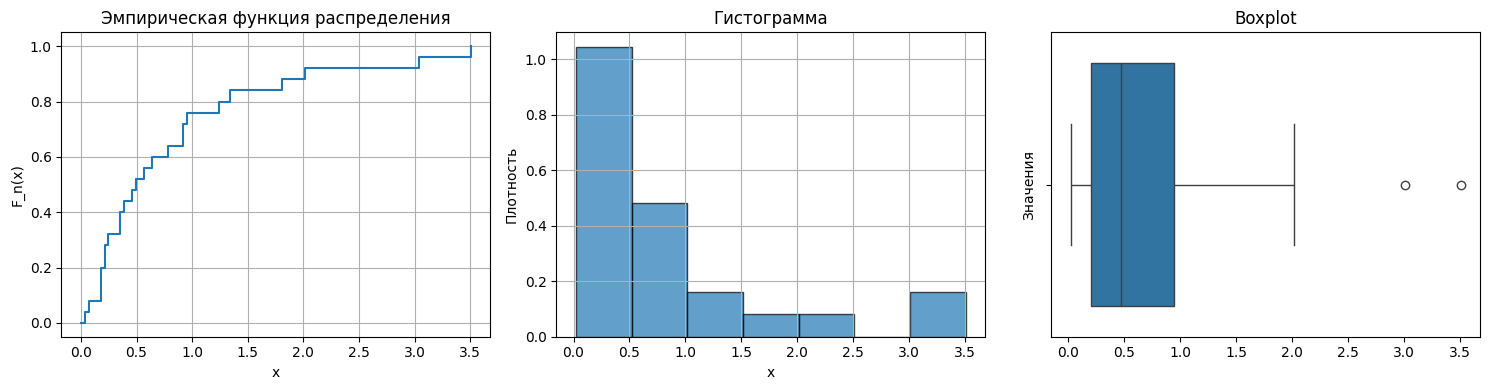

In [192]:
# b)

ecdf = ECDF(sample)
x_ecdf = np.linspace(0, max(sample), 100)
y_ecdf = ecdf(x_ecdf)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.step(x_ecdf, y_ecdf, where='post')
plt.title('Эмпирическая функция распределения')
plt.xlabel('x')
plt.ylabel('F_n(x)')
plt.grid()

plt.subplot(1, 3, 2)
plt.hist(sample, bins='auto', density=True, alpha=0.7, edgecolor='black')
plt.title('Гистограмма')
plt.xlabel('x')
plt.ylabel('Плотность')
plt.grid()

plt.subplot(1, 3, 3)
sns.boxplot(x=sample)
plt.title('Boxplot')
plt.ylabel('Значения')

plt.tight_layout()
plt.show()

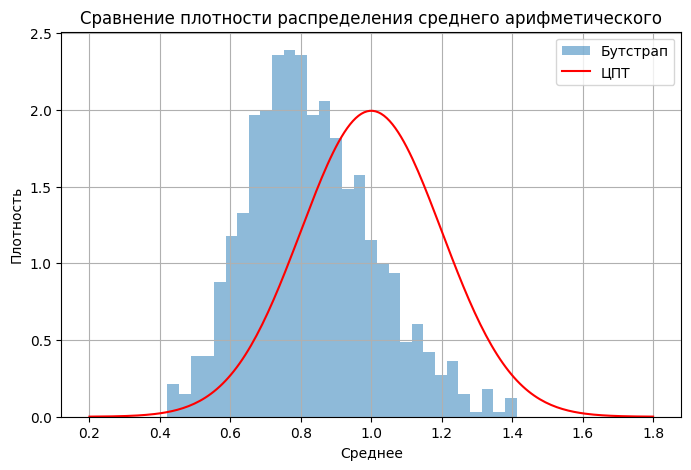

In [193]:
# c)

B = 1000
bootstrap_means = [np.mean(np.random.choice(sample, size=n, replace=True)) for _ in range(B)]

x_norm = np.linspace(0.2, 1.8, 200)
norm_density = 1 / np.sqrt(2 * np.pi * 1/n) * np.exp(-(x_norm - 1)**2 / (2 * 1/n))

plt.figure(figsize=(8, 5))
plt.hist(bootstrap_means, bins=30, density=True, alpha=0.5, label='Бутстрап')
plt.plot(x_norm, norm_density, 'r-', label='ЦПТ')
plt.title('Сравнение плотности распределения среднего арифметического')
plt.xlabel('Среднее')
plt.ylabel('Плотность')
plt.legend()
plt.grid()
plt.show()

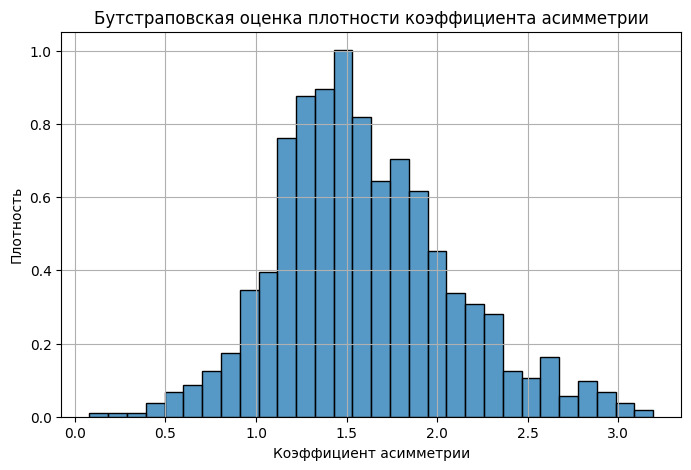

P(коэффициент асимметрии < 1) ≈ 0.088


In [194]:
# d)

bootstrap_skew = [skew(np.random.choice(sample, size=n, replace=True)) for _ in range(B)]

plt.figure(figsize=(8, 5))
sns.histplot(bootstrap_skew, bins=30, stat='density')
plt.title('Бутстраповская оценка плотности коэффициента асимметрии')
plt.xlabel('Коэффициент асимметрии')
plt.ylabel('Плотность')
plt.grid()
plt.show()

prob_skew_less_1 = np.mean(np.array(bootstrap_skew) < 1)
print(f"P(коэффициент асимметрии < 1) ≈ {prob_skew_less_1:.3f}")

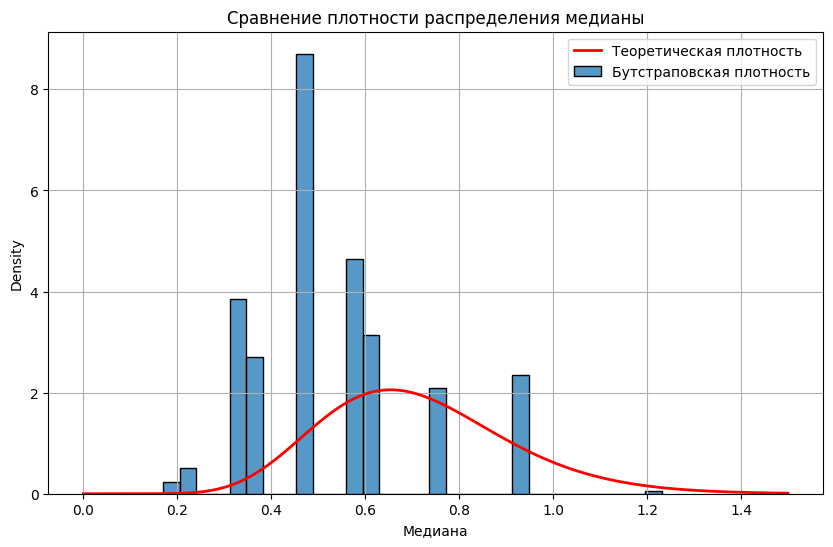

In [195]:
# e)

def median_pdf(x, n):
    k = (n + 1) // 2
    f_x = stats.expon.pdf(x)
    F_x = stats.expon.cdf(x)
    # Формула плотности k-й порядковой статистики
    return (factorial(n) / (factorial(k-1) * factorial(n-k))) * (F_x**(k-1)) * ((1-F_x)**(n-k)) * f_x

bootstrap_medians = [np.median(np.random.choice(sample, size=n, replace=True)) for _ in range(B)]

x_med = np.linspace(0, 1.5, 200)
y_med = median_pdf(x_med, n)

plt.figure(figsize=(10, 6))
sns.histplot(bootstrap_medians, label='Бутстраповская плотность', bins=30, stat='density')
plt.plot(x_med, y_med, 'r-', lw=2, label='Теоретическая плотность')
plt.title("Сравнение плотности распределения медианы")
plt.xlabel("Медиана")
plt.legend()
plt.grid()
plt.show()
